In [27]:
import gzip
import os

# Define paths for the files you want to inspect
target_files = ["../data/reference/Sus_scrofa.Sscrofa11.1.cdna.all.fa.gz"]

for target_file in target_files:
    filename = os.path.basename(target_file)
    open_fn = gzip.open if target_file.endswith(".gz") else open

    first_5_lines = []
    total_lines = 0
    max_line_length = 0
    transcript_count = 0
    unique_genes = set()  # Set to track distinct gene IDs

    # Stream through the file to gather shape metrics and preview lines
    with open_fn(target_file, "rt") as handle:
        for line in handle:
            total_lines += 1
            clean_line = line.rstrip("\r\n")

            # Track Transcripts and Genes from header lines
            if line.startswith(">"):
                transcript_count += 1

                # Find and extract the 'gene:...' field
                for part in line.split():
                    if part.startswith("gene:"):
                        gene_id = part.split(":", 1)[1]
                        unique_genes.add(gene_id)
                        break

            # Store the first 5 lines
            if len(first_5_lines) < 5:
                first_5_lines.append(clean_line)

            # Track maximum line length (columns)
            if len(clean_line) > max_line_length:
                max_line_length = len(clean_line)

    # Print header, shape, metrics, and preview
    print(f"\n{'='*10} File: {filename} {'='*10}")
    print(
        f"Shape (Total Lines, Max Width): ({total_lines:,}, {max_line_length:,})"
    )
    print(f"Total Unique Transcripts: {transcript_count:,}")
    print(f"Total Unique Genes:       {len(unique_genes):,}")
    print("-" * 40)
    print("First 5 lines:")
    for line in first_5_lines:
        print(line)


========== File: Sus_scrofa.Sscrofa11.1.cdna.all.fa.gz ==========
Shape (Total Lines, Max Width): (2,487,484, 357)
Total Unique Transcripts: 46,369
Total Unique Genes:       22,516
----------------------------------------
First 5 lines:
>ENSSSCT00000002339.4 cdna primary_assembly:Sscrofa11.1:AEMK02000555.1:34878:35168:1 gene:ENSSSCG00000035087.2 gene_biotype:TR_V_gene transcript_biotype:TR_V_gene
AAACAGCATGTGAATCAGAGCCACGAAGCCCTGAGCGTCCGAGAGGGAGACGGCTTGGTT
CTCAACTGCAGTTACACCGATAGCGCTATTTACTTCCTTCAGTGGTTTAGGCAGTATCCT
GGGAAAGGGCTTACTTCTCTGCTGTTAATTCAAGCGAACCAGGGAGAACAAATAAGTGGA
AGAATTAAAGCCTCATTGGATAAATCGTCAAGAAACAGTGTTTTCTACATTGCAGCATCT


# Inspecting dmd_splicing_matrix.csv

In [7]:
import pandas as pd

# Load the dataset and display the first 10 rows
# Note: Set index_col=0 if the first column contains exon/sample IDs rather than data
df = pd.read_csv('../data/processed/dmd_splicing_matrix.csv')
df.head(10)

,Transcript_ID,SRR32086846,SRR32086848,SRR32086850,SRR32086830,SRR32086832,SRR32086836,mean_TPM_WT,mean_TPM_DMD,fold_change,Gene_ID,IF_DMD
0,ENSSSCT00000019660,562.342977,459.901549,410.499472,444.081637,639.670911,448.405534,477.581333,510.719361,1.069386,ENSSSCG00000018065,1.0
1,ENSSSCT00000019664,353.471098,294.663002,317.050255,566.155260,472.968795,613.225246,321.728118,550.783100,1.711930,ENSSSCG00000018069,1.0
2,ENSSSCT00000019670,492.417681,485.020705,523.073988,1550.417623,1507.943906,1685.700721,500.170791,1581.354083,3.161585,ENSSSCG00000018075,1.0
3,ENSSSCT00000019673,1501.266861,1234.910440,1333.636342,3458.803243,3080.935513,3808.535173,1356.604548,3449.424643,2.542678,ENSSSCG00000018078,1.0
4,ENSSSCT00000019675,4750.440351,4860.873425,3835.651857,11075.955685,5320.894984,15203.767630,4482.321878,10533.539433,2.350016,ENSSSCG00000018080,1.0
5,ENSSSCT00000019676,1814.242782,1601.845506,1668.235333,4007.353767,3512.995469,3763.796365,1694.774540,3761.381867,2.219392,ENSSSCG00000018081,1.0
6,ENSSSCT00000019677,3065.286116,2635.257720,2631.801542,7223.399297,5776.443949,6841.071075,2777.448459,6613.638107,2.381187,ENSSSCG00000018082,1.0
7,ENSSSCT00000019679,2691.106610,1965.548180,1751.764998,4732.910664,3721.860202,4432.149104,2136.139929,4295.639990,2.010931,ENSSSCG00000018084,1.0
8,ENSSSCT00000019681,443.369343,574.176580,444.593774,430.726665,764.623538,943.581907,487.379899,712.977370,1.462869,ENSSSCG00000018086,1.0
9,ENSSSCT00000019682,1014.295160,985.426352,868.591373,1644.058214,1449.126815,1755.543868,956.104295,1616.242966,1.690439,ENSSSCG00000018087,1.0


In [9]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Configure plot styling
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

# Load dataset
df = pd.read_csv('../data/processed/dmd_splicing_matrix.csv')

# Quick metric check
print("Dataset dimensions:", df.shape)
df[["mean_TPM_WT", "mean_TPM_DMD", "fold_change", "IF_DMD"]].describe()

Dataset dimensions: (19700, 12)


,mean_TPM_WT,mean_TPM_DMD,fold_change,IF_DMD
count,19700.000000,19700.000000,19700.000000,19700.000000
mean,50.757934,50.758485,17.467977,0.647588
std,1462.642296,1467.472266,342.754402,0.410230
min,0.000000,0.000000,0.000144,0.000000
25%,0.283807,0.279550,0.529672,0.197894
50%,1.209885,1.245912,1.055800,0.935540
75%,4.978635,5.395528,2.005854,0.999993
max,143393.188954,146753.071718,41445.132900,1.000000


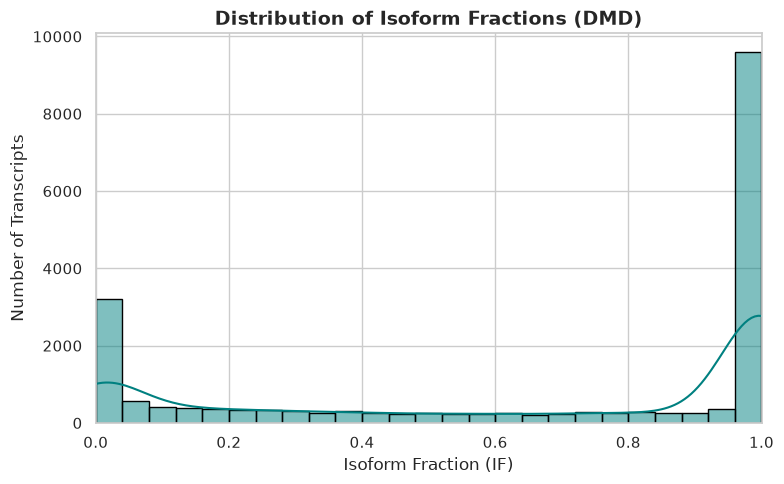

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

# Plot the distribution of Isoform Fractions in DMD
sns.histplot(
    df["IF_DMD"].dropna(), 
    bins=25, 
    kde=True, 
    color="teal", 
    edgecolor="black"
)

plt.title("Distribution of Isoform Fractions (DMD)", fontsize=14, fontweight="bold")
plt.xlabel("Isoform Fraction (IF)", fontsize=12)
plt.ylabel("Number of Transcripts", fontsize=12)  # Fixed unit!
plt.xlim(0, 1)

plt.tight_layout()
plt.show()

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 7))

# Scatter plot comparing Wild Type vs DMD Isoform Fractions
sns.scatterplot(
    data=df,
    x="IF_WT",
    y="IF_DMD",
    alpha=0.3,  # Set transparency so overlapping points stand out
    color="teal",
    s=15,
)

# Diagonal reference line (y = x)
plt.plot([0, 1], [0, 1], color="red", linestyle="--", label="No Change")

plt.title("Isoform Fraction Shift (WT vs DMD)", fontsize=13, fontweight="bold")
plt.xlabel("Isoform Fraction in WT (IF_WT)")
plt.ylabel("Isoform Fraction in DMD (IF_DMD)")
plt.legend()
plt.tight_layout()
plt.show()

ValueError: Could not interpret value `IF_WT` for `x`. An entry with this name does not appear in `data`.

<Figure size 700x700 with 0 Axes>

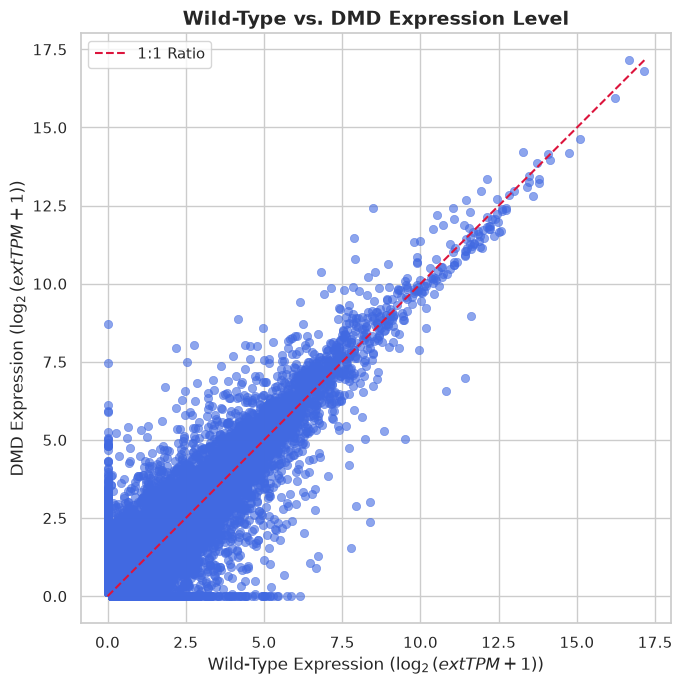

In [7]:
# Apply log2 transformation to compress large dynamic ranges (adding +1 pseudo-count to handle 0s)
log_wt = np.log2(df["mean_TPM_WT"] + 1)
log_dmd = np.log2(df["mean_TPM_DMD"] + 1)

plt.figure(figsize=(7, 7))
sns.scatterplot(x=log_wt, y=log_dmd, alpha=0.6, color="royalblue", edgecolor=None)

# Add 1:1 diagonal reference line
max_val = max(log_wt.max(), log_dmd.max())
plt.plot(
    [0, max_val], [0, max_val], color="crimson", linestyle="--", label="1:1 Ratio"
)

plt.title(
    "Wild-Type vs. DMD Expression Level", fontsize=14, fontweight="bold"
)
plt.xlabel("Wild-Type Expression ($\log_2(\text{TPM} + 1)$)", fontsize=12)
plt.ylabel("DMD Expression ($\log_2(\text{TPM} + 1)$)", fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

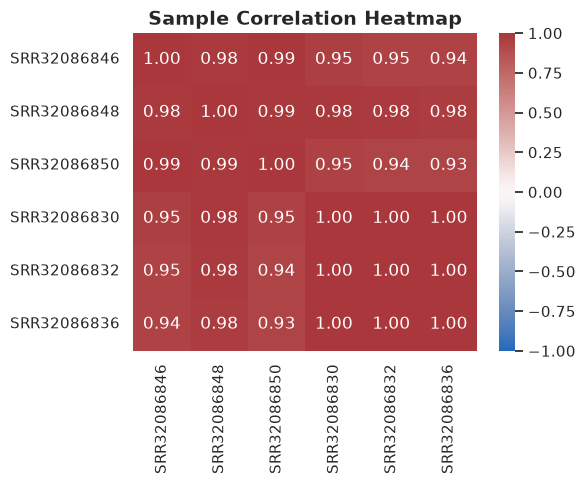

In [9]:
# Identify all sample columns starting with 'SRR'
srr_cols = [col for col in df.columns if col.startswith("SRR")]

if len(srr_cols) >= 2:
    plt.figure(figsize=(6, 5))
    corr_matrix = df[srr_cols].corr()

    sns.heatmap(corr_matrix, annot=True, cmap="vlag", vmin=-1, vmax=1, fmt=".2f")
    plt.title("Sample Correlation Heatmap", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print("Fewer than 2 SRR sample columns found for pairwise correlation.")

# Extracting Gene Names From Raw Data

In [28]:
import gzip
from pathlib import Path
import pandas as pd

# Load existing splicing matrix
df = pd.read_csv("../data/processed/dmd_splicing_matrix.csv")

# Extract Gene_ID -> Gene_Name map from FASTA
fasta_path = Path("../data/reference/Sus_scrofa.Sscrofa11.1.cdna.all.fa.gz")
gene_map = {}

with gzip.open(fasta_path, "rt") as handle:
    for line in handle:
        if line.startswith(">"):
            parts = line.strip().split()
            gene_id, gene_name = None, None

            for part in parts:
                if part.startswith("gene:"):
                    gene_id = part.split(":")[1].split(".")[0]
                elif part.startswith("gene_symbol:"):
                    gene_name = part.split(":")[1]

            if gene_id and gene_name:
                gene_map[gene_id] = gene_name

# Map names and fall back to Gene_ID if no symbol exists
df["Gene_Name"] = df["Gene_ID"].map(gene_map).fillna(df["Gene_ID"])

# Save updated CSV
df.to_csv("../data/processed/dmd_splicing_matrix.csv", index=False)
print(f"Mapped {df['Gene_Name'].nunique()} unique gene names.")
df[["Transcript_ID", "Gene_ID", "Gene_Name", "IF_DMD"]].head()

Mapped 13473 unique gene names.


,Transcript_ID,Gene_ID,Gene_Name,IF_DMD
0,ENSSSCT00000019660,ENSSSCG00000018065,ND1,1.0
1,ENSSSCT00000019664,ENSSSCG00000018069,ND2,1.0
2,ENSSSCT00000019670,ENSSSCG00000018075,COX1,1.0
3,ENSSSCT00000019673,ENSSSCG00000018078,COX2,1.0
4,ENSSSCT00000019675,ENSSSCG00000018080,ATP8,1.0


In [14]:
# Compute WT Isoform Fraction if not already in your dataframe
wt_totals = df.groupby("Gene_ID")["mean_TPM_WT"].transform("sum")
df["IF_WT"] = df["mean_TPM_WT"] / (wt_totals + 1e-5)

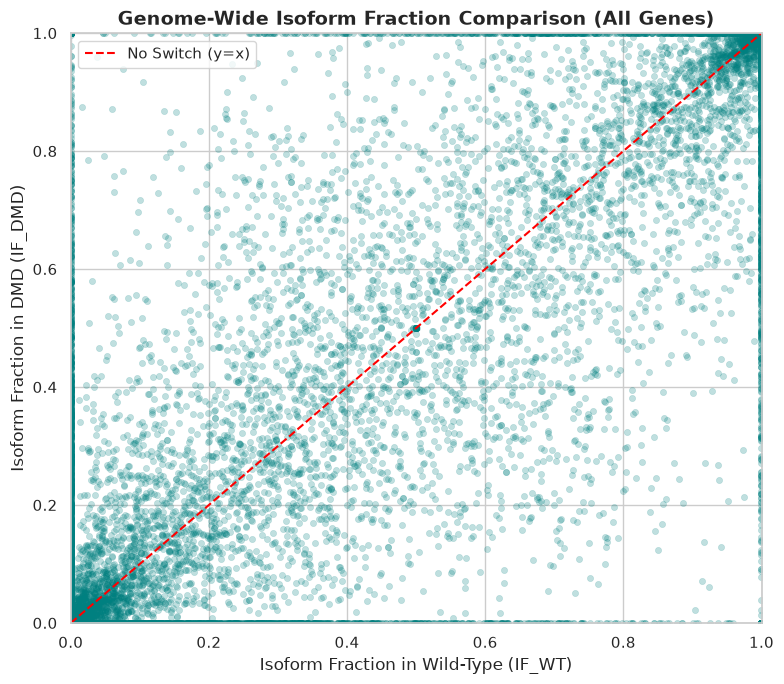

In [16]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 1. Calculate IF_WT and Delta IF across all rows
wt_totals = df.groupby("Gene_ID")["mean_TPM_WT"].transform("sum")
df["IF_WT"] = df["mean_TPM_WT"] / (wt_totals + 1e-5)
df["delta_IF"] = df["IF_DMD"] - df["IF_WT"]

# 2. Create the scatter plot
plt.figure(figsize=(8, 7))

# Alpha transparency is crucial because thousands of points overlap
sns.scatterplot(
    data=df,
    x="IF_WT",
    y="IF_DMD",
    alpha=0.25,
    color="teal",
    s=20,
    edgecolor=None,
)

# Reference diagonal line (y = x)
plt.plot([0, 1], [0, 1], color="red", linestyle="--", linewidth=1.5, label="No Switch (y=x)")

plt.title("Genome-Wide Isoform Fraction Comparison (All Genes)", fontsize=14, fontweight="bold")
plt.xlabel("Isoform Fraction in Wild-Type (IF_WT)", fontsize=12)
plt.ylabel("Isoform Fraction in DMD (IF_DMD)", fontsize=12)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend(loc="upper left")

plt.tight_layout()
plt.show()

In [22]:
import numpy as np
import pandas as pd

# 1. Compute total gene expression (Activity) per gene
df["gene_total_tpm"] = df.groupby("Gene_ID")["mean_TPM_DMD"].transform("sum")
df["IF_WT"] = df["mean_TPM_WT"] / (
    df.groupby("Gene_ID")["mean_TPM_WT"].transform("sum") + 1e-5
)
df["delta_IF"] = df["IF_DMD"] - df["IF_WT"]

# 2. Filter for HIGH ACTIVITY + SIGNIFICANT SWITCHING
# - Total Gene TPM >= 10 (filters out low-count noise)
# - |Delta IF| >= 0.20 (at least a 20% shift in isoform fraction)
active_switches = df[
    (df["gene_total_tpm"] >= 10) & (df["delta_IF"].abs() >= 0.20)
].copy()

# 3. Deduplicate to get 1 representative switch per gene
top_active_genes = (
    active_switches.reindex(
        active_switches["delta_IF"].abs().sort_values(ascending=False).index
    )
    .drop_duplicates(subset=["Gene_Name"])
    .sort_values(by="gene_total_tpm", ascending=False)
)

print(
    f"Found {top_active_genes['Gene_Name'].nunique()} highly active genes with major isoform switches."
)

Found 294 highly active genes with major isoform switches.


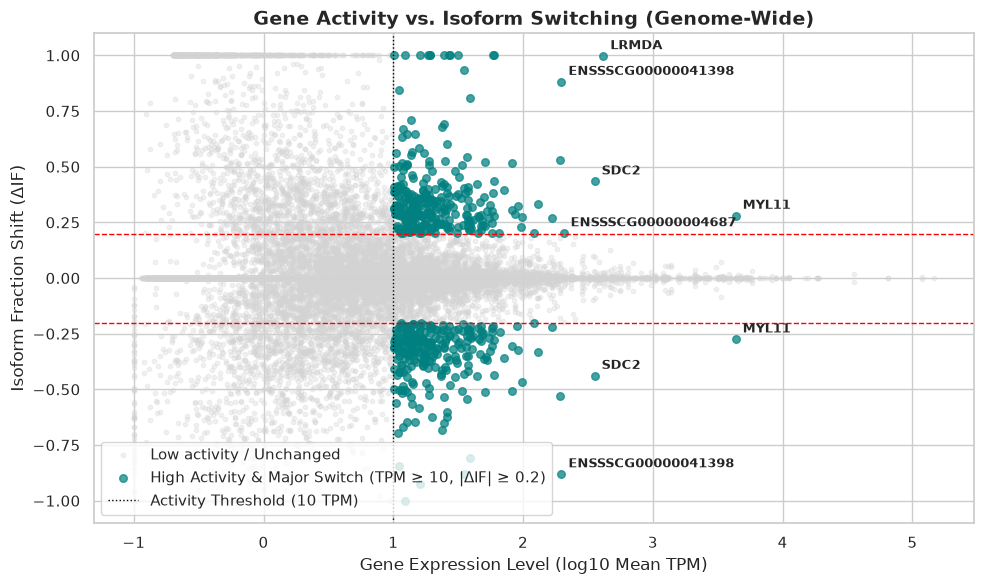

In [24]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Calculate Log10 Total TPM for plot scaling
df["log_gene_tpm"] = np.log10(df["gene_total_tpm"] + 0.1)

plt.figure(figsize=(10, 6))

# Plot all background transcripts
plt.scatter(
    df["log_gene_tpm"],
    df["delta_IF"],
    color="lightgray",
    alpha=0.3,
    s=10,
    label="Low activity / Unchanged",
)

# Highlight high-activity switching transcripts (fixed color name)
high_act = df[(df["gene_total_tpm"] >= 10) & (df["delta_IF"].abs() >= 0.2)]
plt.scatter(
    high_act["log_gene_tpm"],
    high_act["delta_IF"],
    color="teal",  # Changed from 'darkteal' to valid color 'teal' (or 'darkcyan' / '#006666')
    alpha=0.7,
    s=30,
    label="High Activity & Major Switch (TPM ≥ 10, |ΔIF| ≥ 0.2)",
)

# Threshold lines
plt.axhline(0.2, color="red", linestyle="--", linewidth=1)
plt.axhline(-0.2, color="red", linestyle="--", linewidth=1)
plt.axvline(
    1,
    color="black",
    linestyle=":",
    linewidth=1,
    label="Activity Threshold (10 TPM)",
)

# Label top 8 most active switching genes
top_labels = high_act.sort_values(by="gene_total_tpm", ascending=False).head(8)
for _, row in top_labels.iterrows():
    plt.annotate(
        row["Gene_Name"],
        (row["log_gene_tpm"], row["delta_IF"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9,
        fontweight="bold",
    )

plt.title(
    "Gene Activity vs. Isoform Switching (Genome-Wide)",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Gene Expression Level (log10 Mean TPM)", fontsize=12)
plt.ylabel("Isoform Fraction Shift (ΔIF)", fontsize=12)
plt.legend(loc="lower left")
plt.tight_layout()
plt.show()

# Obtaining Gene information per id 

In [2]:
import gzip
from pathlib import Path
import mygene
import pandas as pd

# Step 1: Read unique Gene_IDs from the splicing matrix
print("[1/4] Extracting unique Gene IDs from matrix...")
matrix_path = Path("../data/processed/dmd_splicing_matrix.csv")
df = pd.read_csv(matrix_path, usecols=["Gene_ID"])
unique_gene_ids = df["Gene_ID"].dropna().unique().tolist()

# Step 2: Extract Gene_ID -> Gene_Name map from FASTA
fasta_path = Path("../data/reference/Sus_scrofa.Sscrofa11.1.cdna.all.fa.gz")
gene_map = {}

print(f"[2/4] Parsing FASTA ({fasta_path.name})... Please wait ~30-60 seconds.")
line_count = 0
with gzip.open(fasta_path, "rt") as handle:
    for line in handle:
        line_count += 1
        if line_count % 1000000 == 0:
            print(f"      ...processed {line_count:,} lines...")

        if line.startswith(">"):
            parts = line.strip().split()
            gene_id, gene_name = None, None

            for part in parts:
                if part.startswith("gene:"):
                    gene_id = part.split(":")[1].split(".")[0]
                elif part.startswith("gene_symbol:"):
                    gene_name = part.split(":")[1]

            if gene_id and gene_name:
                gene_map[gene_id] = gene_name

print(f"      [✓] Mapped {len(gene_map):,} gene IDs from FASTA.")

# Create base mapping DataFrame for dataset genes
mapping_df = pd.DataFrame({"Gene_ID": unique_gene_ids})
mapping_df["Gene_Name"] = mapping_df["Gene_ID"].map(gene_map).fillna(
    mapping_df["Gene_ID"]
)

# Step 3: Query MyGene using built-in batching
unique_genes_to_query = mapping_df["Gene_Name"].unique().tolist()
print(
    f"[3/4] Querying MyGene.info for {len(unique_genes_to_query):,} unique genes..."
)

mg = mygene.MyGeneInfo()
results = mg.querymany(
    unique_genes_to_query,
    scopes=["symbol", "ensembl.gene"],
    fields=["name", "summary", "go.BP"],
    species="pig,human",
    step=1000,
    as_dataframe=False,
)

# Step 4: Parse MyGene API responses & Save Mapping CSV
print("[4/4] Parsing functional terms & saving standalone gene mapping file...")
annotations = {}
for res in results:
    query_key = res.get("query")
    if not query_key or query_key in annotations:
        continue

    full_description = res.get("name", None)
    summary = res.get("summary", None)

    go_bp_list = []
    go_data = (
        res.get("go", {}).get("BP", [])
        if isinstance(res.get("go"), dict)
        else []
    )

    if isinstance(go_data, dict):
        go_data = [go_data]

    for term in go_data:
        if isinstance(term, dict) and "term" in term:
            go_bp_list.append(term["term"])

    go_bp_str = "; ".join(list(set(go_bp_list))[:5]) if go_bp_list else None

    annotations[query_key] = {
        "Gene_Description": full_description,
        "Gene_Summary": summary,
        "GO_Biological_Process": go_bp_str,
    }

anno_df = pd.DataFrame.from_dict(annotations, orient="index").reset_index()
anno_df.rename(columns={"index": "Gene_Name"}, inplace=True)

# Merge annotations into mapping lookup table
mapping_full = mapping_df.merge(anno_df, on="Gene_Name", how="left")

# Save dedicated gene mapping CSV
map_output_path = Path("../data/processed/gene_id_to_name_mapping.csv")
mapping_full.to_csv(map_output_path, index=False)

print(f"[✓] Done! Gene lookup table saved to: {map_output_path}")

[1/4] Extracting unique Gene IDs from matrix...
[2/4] Parsing FASTA (Sus_scrofa.Sscrofa11.1.cdna.all.fa.gz)... Please wait ~30-60 seconds.
      ...processed 1,000,000 lines...
      ...processed 2,000,000 lines...
      [✓] Mapped 15,815 gene IDs from FASTA.
[3/4] Querying MyGene.info for 13,473 unique genes...


11282 input query terms found dup hits:	[('SH3YL1', 2), ('FAM110C', 2), ('EDIL3', 2), ('COX7C', 2), ('CETN3', 2), ('MBLAC2', 2), ('LYSMD3', 
126 input query terms found no hit:	['C12orf29', 'C12orf50', 'MFSD3', 'ENSSSCG00000005901', 'ENSSSCG00000053412', 'MDM1', 'BVES', 'MFSD9


[4/4] Parsing functional terms & saving standalone gene mapping file...
[✓] Done! Gene lookup table saved to: ../data/processed/gene_id_to_name_mapping.csv
